<a href="https://colab.research.google.com/github/ewiw24/cvd-risk-classification-shap/blob/main/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
✅ Setup complete
Raw dataset: (70000, 13)
After cleaning: 68,465 rows
Removed: 1,535 (2.19%)
BMI distribution:
bmi_category
Underweight      634
Normal         25389
Overweight     24598
Obese          17844
Name: count, dtype: int64

BP staging distribution:
bp_category
Normal          9518
Elevated        3094
Stage 1 HTN    41642
Stage 2 HTN    14086
HTN Crisis       125
Name: count, dtype: int64
Tercile boundaries: 50.2 yrs | 57.4 yrs

Age group distribution:
  [0] Younger Adult (≤50 yrs): 22,597 (33.0%)
  [1] Middle-Aged (51–57 yrs): 23,286 (34.0%)
  [2] Older Adult (>57 yrs): 22,582 (33.0%)

Lifestyle score distribution:
lifestyle_score
Healthiest    48415
Moderate      17237
Unhealthy      2536
Worst           277
Name: count, dtype: int64
Train set: 54,772 samples
Test set : 13,693  samples

Class balance (train):
cardio
0    50.52
1    49.48
Name: proportion, dtype: float64

Class balance (test):
cardio
0    50.52
1    49.48
Name: proportion, dtype: f

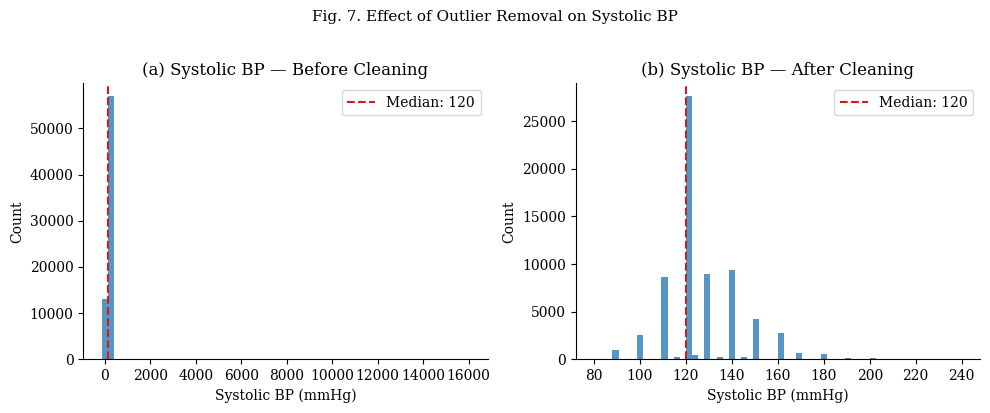


✅ Preprocessing complete
   Final dataset : 68,465 records
   Features      : 14
   New features  : bmi, bmi_category, bp_category,
                   age_group, lifestyle_score
   Saved to      : /content/drive/MyDrive/CVD_Project/phase2_state.pkl


In [1]:
# ── MARKDOWN ──────────────────────────────────────────────────
# # 02 — Feature Engineering & Preprocessing
# **Goal:** Clean data, engineer features, create train/test
# split, and prepare age-stratified subsets for modeling.

# ── CELL 1: Setup ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

SAVE_DIR = '/content/drive/MyDrive/CVD_Project'
PALETTE  = ['#2c7bb6', '#d7191c']

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
print("✅ Setup complete")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 1. Load & Clean Data

# ── CELL 2: Load ──────────────────────────────────────────────
df = pd.read_csv(f'{SAVE_DIR}/cardio_train.csv', sep=';')
df.drop(columns=['id'], inplace=True)
df['age_years'] = df['age'] / 365.25
print(f"Raw dataset: {df.shape}")

# ── CELL 3: Outlier Removal ───────────────────────────────────
n_before = len(df)

df = df[
    (df['ap_hi'] >= 80)   & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 50)   & (df['ap_lo'] <= 150) &
    (df['ap_lo'] < df['ap_hi'])                   &
    (df['height'] >= 140) & (df['height'] <= 210) &
    (df['weight'] >= 30)  & (df['weight'] <= 180)
].copy()

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

n_after = len(df)
print(f"After cleaning: {n_after:,} rows")
print(f"Removed: {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.2f}%)")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 2. Feature Engineering
# Four derived features following paper methodology:
# - BMI (WHO categories)
# - BP Category (AHA 2017 staging)
# - Age Group (tercile-based due to dataset age distribution)
# - Composite Lifestyle Score

# ── CELL 4: BMI ───────────────────────────────────────────────
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2

def classify_bmi(bmi):
    if bmi < 18.5: return 0   # Underweight
    elif bmi < 25: return 1   # Normal
    elif bmi < 30: return 2   # Overweight
    else:          return 3   # Obese

df['bmi_category'] = df['bmi'].apply(classify_bmi)
print("BMI distribution:")
print(df['bmi_category'].value_counts().sort_index()
      .rename({0:'Underweight',1:'Normal',2:'Overweight',3:'Obese'}))

# ── CELL 5: Blood Pressure Staging (AHA 2017) ────────────────
def classify_bp(row):
    s, d = row['ap_hi'], row['ap_lo']
    if   s < 120 and d < 80:  return 0   # Normal
    elif s < 130 and d < 80:  return 1   # Elevated
    elif s < 140 or  d < 90:  return 2   # Stage 1 HTN
    elif s < 180 or  d < 120: return 3   # Stage 2 HTN
    else:                      return 4   # Hypertensive Crisis

df['bp_category'] = df.apply(classify_bp, axis=1)
bp_labels = {0:'Normal',1:'Elevated',2:'Stage 1 HTN',
             3:'Stage 2 HTN',4:'HTN Crisis'}
print("\nBP staging distribution:")
print(df['bp_category'].value_counts().sort_index().rename(bp_labels))

# ── CELL 6: Age Group (Tercile-Based) ─────────────────────────
# Note: Dataset age range is 29.6–64.9 yrs
# WHO Young Adult (18–39) < 0.1% of data
# Tercile boundaries ensure adequate subgroup sample sizes

q33 = df['age_years'].quantile(0.33)
q67 = df['age_years'].quantile(0.67)
print(f"Tercile boundaries: {q33:.1f} yrs | {q67:.1f} yrs")

def classify_age(age):
    if   age <= q33: return 0   # Younger Adult
    elif age <= q67: return 1   # Middle-Aged Adult
    else:            return 2   # Older Adult

df['age_group'] = df['age_years'].apply(classify_age)

AGE_LABELS = {
    0: f'Younger Adult (≤{int(q33)} yrs)',
    1: f'Middle-Aged ({int(q33)+1}–{int(q67)} yrs)',
    2: f'Older Adult (>{int(q67)} yrs)',
}
print("\nAge group distribution:")
for gid, label in AGE_LABELS.items():
    n = (df['age_group'] == gid).sum()
    print(f"  [{gid}] {label}: {n:,} ({n/len(df)*100:.1f}%)")

# ── CELL 7: Composite Lifestyle Score ────────────────────────
# 0 = healthiest (non-smoker, no alcohol, physically active)
# 3 = most unhealthy
df['lifestyle_score'] = (
    df['smoke'] + df['alco'] + (1 - df['active'])
)
print("\nLifestyle score distribution:")
print(df['lifestyle_score'].value_counts().sort_index()
      .rename({0:'Healthiest',1:'Moderate',2:'Unhealthy',3:'Worst'}))

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 3. Train/Test Split & Scaling

# ── CELL 8: Split & Scale ─────────────────────────────────────
FEATURES = [
    'age_years', 'gender', 'bmi', 'bmi_category',
    'ap_hi', 'ap_lo', 'bp_category',
    'cholesterol', 'gluc',
    'smoke', 'alco', 'active', 'lifestyle_score',
    'age_group'
]
TARGET = 'cardio'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale continuous features only — fit on train, transform both
scale_cols = ['age_years', 'bmi', 'ap_hi', 'ap_lo']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f"Train set: {len(X_train_scaled):,} samples")
print(f"Test set : {len(X_test_scaled):,}  samples")
print(f"\nClass balance (train):")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print(f"\nClass balance (test):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

# ── CELL 9: Age-Stratified Subsets ───────────────────────────
stratified_data = {}
for group_id, group_name in AGE_LABELS.items():
    mask_train = X_train_scaled['age_group'] == group_id
    mask_test  = X_test_scaled['age_group']  == group_id
    stratified_data[group_id] = {
        'name'   : group_name,
        'X_train': X_train_scaled[mask_train],
        'X_test' : X_test_scaled[mask_test],
        'y_train': y_train[mask_train],
        'y_test' : y_test[mask_test],
    }
    n_tr = mask_train.sum()
    n_te = mask_test.sum()
    print(f"[{group_id}] {group_name}: Train={n_tr:,} | Test={n_te:,}")

# ── MARKDOWN ──────────────────────────────────────────────────
# ## 4. Validation Plot: Before vs After Cleaning

# ── CELL 10: Fig 7 — Cleaning Validation ─────────────────────
df_raw = pd.read_csv(f'{SAVE_DIR}/cardio_train.csv', sep=';')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(axes,
    [df_raw['ap_hi'], df['ap_hi']],
    ['(a) Systolic BP — Before Cleaning',
     '(b) Systolic BP — After Cleaning']):
    ax.hist(data, bins=60, color='#2c7bb6',
            edgecolor='none', alpha=0.8)
    ax.set_xlabel('Systolic BP (mmHg)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.axvline(data.median(), color='#d7191c', linestyle='--',
               linewidth=1.5,
               label=f'Median: {data.median():.0f}')
    ax.legend()

plt.suptitle('Fig. 7. Effect of Outlier Removal on Systolic BP',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig7_cleaning_validation.png')
plt.show()

# ── CELL 11: Save State ───────────────────────────────────────
state = {
    'X_train_scaled' : X_train_scaled,
    'X_test_scaled'  : X_test_scaled,
    'y_train'        : y_train,
    'y_test'         : y_test,
    'stratified_data': stratified_data,
    'FEATURES'       : FEATURES,
    'AGE_LABELS'     : AGE_LABELS,
    'scaler'         : scaler,
    'df'             : df,
}
with open(f'{SAVE_DIR}/phase2_state.pkl', 'wb') as f:
    pickle.dump(state, f)

print("\n✅ Preprocessing complete")
print(f"   Final dataset : {len(df):,} records")
print(f"   Features      : {len(FEATURES)}")
print(f"   New features  : bmi, bmi_category, bp_category,")
print(f"                   age_group, lifestyle_score")
print(f"   Saved to      : {SAVE_DIR}/phase2_state.pkl")